# Sheet 8 — Audio: the tonal-centroid ("tonnetz") feature (Chapter 8)

Harte, Sandler & Gasser (2006) map a 12-bin chroma vector to 6-D: two coordinates each for the circle of fifths,
the minor-third circle and the major-third circle. `librosa.feature.tonnetz` implements it; so does `tonnetzkit.tonal_centroid`.

In [1]:
# Setup: make the repository importable whether or not `pip install -e .` was run
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np, networkx as nx, matplotlib.pyplot as plt
from tonnetzkit import *
%matplotlib inline
import librosa, librosa.display
from IPython.display import Audio

max difference ours vs librosa: 2.9201447038218475e-08


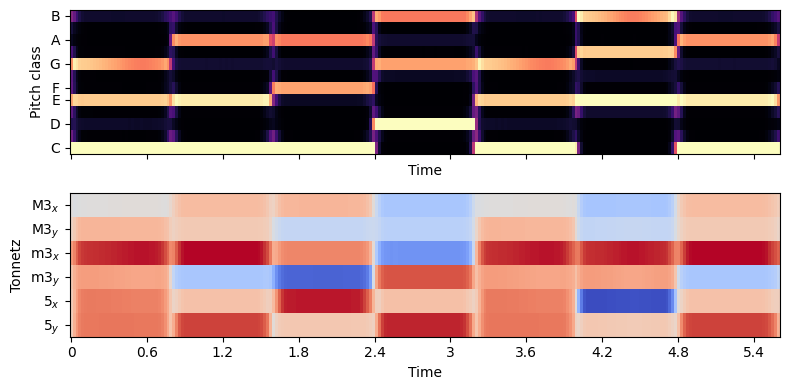

In [2]:
sr = 22050
prog = [Triad.parse(s) for s in 'C Am F G C E Am'.split()]
y = np.concatenate([synth_chord(t.pcs, sr=sr, dur=0.8) for t in prog])
chroma = librosa.feature.chroma_cqt(y=y, sr=sr)
ours, lib = tonal_centroid(chroma), librosa.feature.tonnetz(chroma=chroma)
print('max difference ours vs librosa:', np.abs(ours - lib).max())
fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
librosa.display.specshow(chroma, y_axis='chroma', x_axis='time', ax=ax[0], sr=sr)
librosa.display.specshow(lib, y_axis='tonnetz', x_axis='time', ax=ax[1], sr=sr); plt.tight_layout()
Audio(y, rate=sr)

### Harmonic change detection: distance between successive centroids

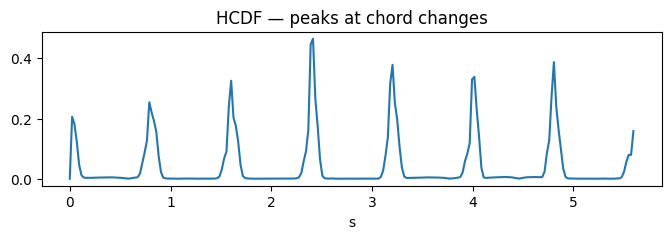

In [3]:
hcdf = np.r_[0, np.linalg.norm(np.diff(lib, axis=1), axis=0)]
t = librosa.times_like(hcdf, sr=sr)
plt.figure(figsize=(8, 2)); plt.plot(t, hcdf); plt.xlabel('s'); plt.title('HCDF — peaks at chord changes'); plt.show()

## Exercises
1. Which pairs of triads are closest in tonal-centroid space? Compare with the PLR distance.
2. Change the circle radii `r=(1,1,0.5)` and observe how the HCDF peaks change for L versus R moves.
<details><summary><b>Show solution</b></summary>

```python
import itertools
T = all_triads()
vec = {t: tonal_centroid(np.isin(np.arange(12), list(t.pcs)).astype(float)) for t in T}
pairs = sorted(itertools.combinations(T, 2), key=lambda ab: np.linalg.norm(vec[ab[0]] - vec[ab[1]]))
D = plr_distance_table(); print([(a, b, D[a][b]) for a, b in pairs[:6]])
```
The nearest pairs are exactly R-related (relative major/minor), then L and P pairs: two shared tones dominate the centroid.

</details>